In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
#Representative radar data
data = pd.read_csv('radar_dc_to_nyc_example.csv', sep=",")

In [4]:
data.head()

,time_s,track_id,lat_deg,lon_deg,alt_m,range_m,azimuth_deg,elevation_deg,radial_velocity_mps,snr_db,rcs_dbsm,x_ecef_m,y_ecef_m,z_ecef_m,vx_ecef_mps,vy_ecef_mps,vz_ecef_mps
0,0.00,1,38.907192,-77.036871,0.000000,0.000000,0.000000,0.000000,0.000000,202.920032,-4.695283,1.112128e+06,-4.831336e+06,4.001375e+06,1081.558051,-233.508023,1400.257318
1,0.25,1,38.908978,-77.033977,311.031842,445.951424,51.583754,44.221878,1782.950755,100.909627,-4.249549,1.112398e+06,-4.831395e+06,4.001725e+06,1081.130086,-231.648847,1398.717525
2,0.50,1,38.910763,-77.031083,621.466798,891.475486,51.583754,44.193648,1781.241953,84.391265,-6.951035,1.112668e+06,-4.831452e+06,4.002074e+06,1080.702122,-229.789672,1397.177732
3,0.75,1,38.912549,-77.028190,931.304865,1336.572509,51.583754,44.165390,1779.534452,79.327814,-4.872160,1.112938e+06,-4.831509e+06,4.002423e+06,1080.274157,-227.930497,1395.637939
4,1.00,1,38.914334,-77.025296,1240.546041,1781.242820,51.583754,44.137106,1777.828254,73.264987,-5.016801,1.113208e+06,-4.831566e+06,4.002772e+06,1079.846193,-226.071321,1394.098146


In [5]:
print(data.shape, data.columns)

(241, 17) Index(['time_s', 'track_id', 'lat_deg', 'lon_deg', 'alt_m', 'range_m',
       'azimuth_deg', 'elevation_deg', 'radial_velocity_mps', 'snr_db',
       'rcs_dbsm', 'x_ecef_m', 'y_ecef_m', 'z_ecef_m', 'vx_ecef_mps',
       'vy_ecef_mps', 'vz_ecef_mps'],
      dtype='object')


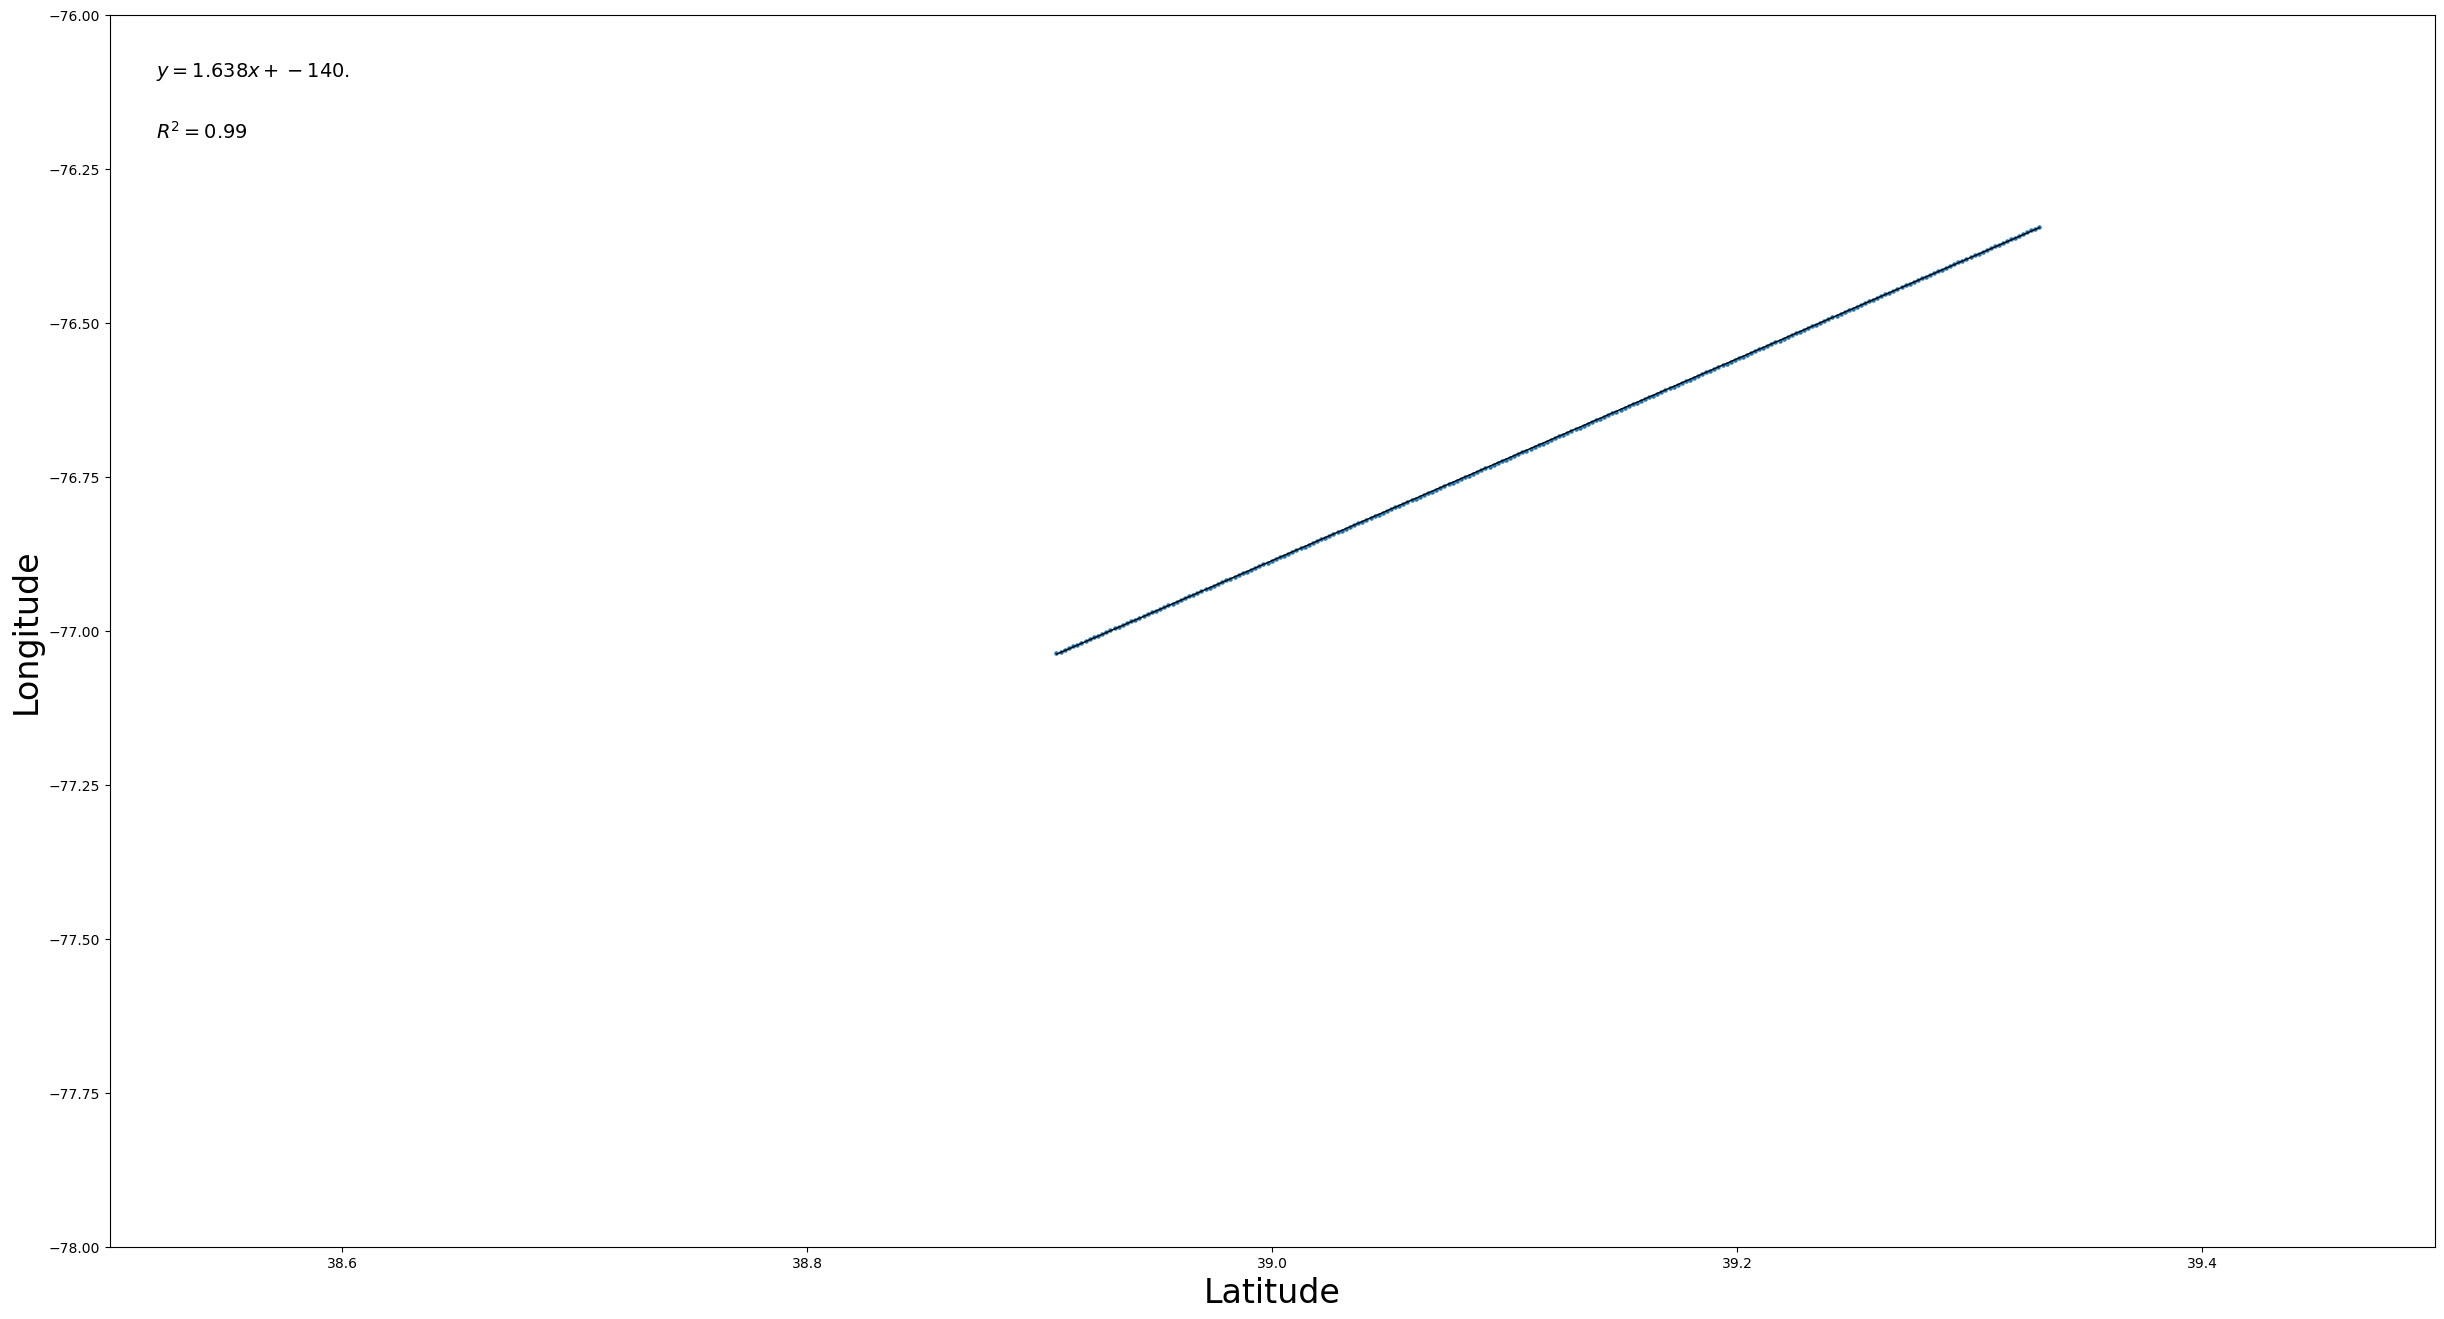

     time_s  track_id    lat_deg    lon_deg         alt_m       range_m  \
0      0.00         1  38.907192 -77.036871      0.000000      0.000000   
1      0.25         1  38.908978 -77.033977    311.031842    445.951424   
2      0.50         1  38.910763 -77.031083    621.466798    891.475486   
3      0.75         1  38.912549 -77.028190    931.304865   1336.572509   
4      1.00         1  38.914334 -77.025296   1240.546041   1781.242820   
..      ...       ...        ...        ...           ...           ...   
236   59.00         1  39.322974 -76.355929  56847.985656  94181.693955   
237   59.25         1  39.324716 -76.353044  57018.107767  94537.288371   
238   59.50         1  39.326459 -76.350160  57187.632699  94892.551833   
239   59.75         1  39.328201 -76.347275  57356.560451  95247.484843   
240   60.00         1  39.329943 -76.344391  57524.891022  95602.087905   

     azimuth_deg  elevation_deg  radial_velocity_mps      snr_db  rcs_dbsm  \
0       0.000000     

In [15]:
#filter for just one trajectory:
track = data[data['track_id'] == 1]
time = track["time_s"]
latitude = track["lat_deg"]
longitude = track["lon_deg"]

#plot the trajectory
plt.figure(figsize=(30,16))

plt.scatter(latitude, longitude, s=5)

plt.xlim([38.5, 39.5])
plt.ylim([-78, -76])

plt.xlabel("Latitude", fontsize=24)
plt.ylabel("Longitude", fontsize=24)

# Use numpy to do a simple linear fit to time series data 
model = np.polyfit(latitude, longitude, 1)
predicted = np.polyval(model, latitude)

plt.plot(latitude, predicted, linewidth=1, color='black')

slope = model[0]
intercept = model[1]
plt.annotate('$y=%3.5sx+%3.5s$'%(slope, intercept), xy=(0.02, 0.95), xycoords='axes fraction', fontsize=14)

r2 = np.corrcoef(longitude, latitude)[0, 1]**2
plt.annotate('$R^2=%3.4s$'%(r2), xy=(0.02, 0.9), xycoords='axes fraction', fontsize=14)

plt.show()

print(track)

In [16]:
"""
radars.py - Radar Site Configuration and ECEF Conversion

This module defines radar sites in geodetic coordinates and converts them
to ECEF for use in the simulation. It provides:
- Radar site definitions (locations, noise parameters, update rates)
- Geodetic to ECEF coordinate conversion
- Measurement covariance matrices for EKF
- Simple scheduling helpers
"""

import math

# -----------------------
# 1) Human-editable radar site definitions
# -----------------------
RADARS = [
    {
        "id": "dc_east_10km",
        "lat_deg": 38.907189,    # computed: 10km east of DC
        "lon_deg": -76.923629,   # computed
        "alt_m": 0.0,
        "update_rate_hz": 2.0,
        "sigma_range_m": 50.0,
        "sigma_az_rad": 0.0009,   # ~0.05 degrees
        "sigma_el_rad": 0.0009,
        "sigma_doppler_mps": 3.0,
        "dropout_prob": 0.05,
    },
    {
        "id": "nyc_west_10km", 
        "lat_deg": 40.730602,    # computed: 10km west of NYC
        "lon_deg": -74.046727,   # computed
        "alt_m": 0.0,
        "update_rate_hz": 2.0,
        "sigma_range_m": 50.0,
        "sigma_az_rad": 0.0009,
        "sigma_el_rad": 0.0009,
        "sigma_doppler_mps": 3.0,
        "dropout_prob": 0.05,
    },
    {
        "id": "midpoint_west_15km",
        "lat_deg": 39.825905,    # computed: 15km west of NYC-DC midpoint
        "lon_deg": -75.694756,   # computed
        "alt_m": 0.0,
        "update_rate_hz": 2.0,
        "sigma_range_m": 50.0,
        "sigma_az_rad": 0.0009,
        "sigma_el_rad": 0.0009,
        "sigma_doppler_mps": 3.0,
        "dropout_prob": 0.05,
    },
    {
        "id": "pennsylvania_radar",
        "lat_deg": 40.051626,    # supplied coordinate
        "lon_deg": -77.344419,   # supplied coordinate
        "alt_m": 0.0,
        "update_rate_hz": 2.0,
        "sigma_range_m": 50.0,
        "sigma_az_rad": 0.0009,
        "sigma_el_rad": 0.0009,
        "sigma_doppler_mps": 3.0,
        "dropout_prob": 0.05,
    },
]

# --------------------------------
# 2) WGS-84 constants and conversion helpers
# --------------------------------
WGS84_A = 6378137.0                 # semi-major axis [m]
WGS84_F = 1.0 / 298.257223563       # flattening
WGS84_E2 = WGS84_F * (2.0 - WGS84_F)  # first eccentricity squared

def deg2rad(degrees):
    """Convert degrees to radians"""
    return degrees * math.pi / 180.0

def geodetic_to_ecef(lat_deg, lon_deg, alt_m):
    """
    Convert geodetic coordinates (WGS-84) to ECEF Cartesian coordinates.
    
    Args:
        lat_deg: latitude in degrees
        lon_deg: longitude in degrees  
        alt_m: altitude above ellipsoid in meters
        
    Returns:
        tuple: (X, Y, Z) in ECEF meters
    """
    φ = deg2rad(lat_deg)
    λ = deg2rad(lon_deg)
    
    sinφ, cosφ = math.sin(φ), math.cos(φ)
    sinλ, cosλ = math.sin(λ), math.cos(λ)
    
    # Prime vertical radius of curvature
    N = WGS84_A / math.sqrt(1.0 - WGS84_E2 * sinφ * sinφ)
    
    # ECEF coordinates
    X = (N + alt_m) * cosφ * cosλ
    Y = (N + alt_m) * cosφ * sinλ
    Z = (N * (1.0 - WGS84_E2) + alt_m) * sinφ
    
    return (X, Y, Z)

def measurement_covariance_diagonal(sigma_range_m, sigma_az_rad, sigma_el_rad, sigma_doppler_mps):
    """
    Create diagonal measurement covariance from noise sigmas.
    
    Args:
        sigma_range_m: range noise standard deviation [m]
        sigma_az_rad: azimuth noise standard deviation [rad]
        sigma_el_rad: elevation noise standard deviation [rad]
        sigma_doppler_mps: doppler noise standard deviation [m/s]
        
    Returns:
        list: diagonal entries [σ_r², σ_az², σ_el², σ_dop²] for R matrix
    """
    return [
        sigma_range_m ** 2,
        sigma_az_rad ** 2,
        sigma_el_rad ** 2,
        sigma_doppler_mps ** 2,
    ]

# -----------------------------------------
# 3) Build math-ready ECEF radar list
# -----------------------------------------
RADARS_ECEF = []

for site in RADARS:
    # Convert geodetic to ECEF once at import time
    x, y, z = geodetic_to_ecef(site["lat_deg"], site["lon_deg"], site["alt_m"])
    
    # Precompute measurement covariance diagonal
    R_diag = measurement_covariance_diagonal(
        site["sigma_range_m"],
        site["sigma_az_rad"], 
        site["sigma_el_rad"],
        site["sigma_doppler_mps"]
    )
    
    # Create enhanced radar entry with ECEF and covariance
    radar_ecef = {
        **site,  # Keep original fields for documentation
        "ecef_m": (x, y, z),     # ECEF position in meters
        "R_diag": R_diag,        # Measurement covariance diagonal
    }
    
    RADARS_ECEF.append(radar_ecef)

# ---------------------------------------------------
# 4) Optional scheduling and utility helpers
# ---------------------------------------------------
def should_radar_emit(prev_time, current_time, update_rate_hz):
    """
    Simple timing check for radar emissions based on update rate.
    
    Args:
        prev_time: previous measurement time
        current_time: current simulation time
        update_rate_hz: radar update rate in Hz
        
    Returns:
        bool: True if enough time has elapsed for next measurement
    """
    if update_rate_hz <= 0:
        return False
    return (current_time - prev_time) >= (1.0 / update_rate_hz)

def get_active_radar_indices(current_time, last_measurement_times):
    """
    Get indices of radars that should emit measurements at current time.
    
    Args:
        current_time: current simulation time
        last_measurement_times: dict mapping radar_id to last measurement time
        
    Returns:
        list: indices of radars that should emit measurements
    """
    active_indices = []
    
    for i, radar in enumerate(RADARS_ECEF):
        radar_id = radar["id"]
        update_rate = radar["update_rate_hz"]
        
        # Get last measurement time (default to 0 if first measurement)
        last_time = last_measurement_times.get(radar_id, 0.0)
        
        if should_radar_emit(last_time, current_time, update_rate):
            active_indices.append(i)
    
    return active_indices

def print_radar_summary():
    """Print a summary of all configured radars"""
    print("\nRadar Site Summary:")
    print("=" * 80)
    for i, radar in enumerate(RADARS_ECEF):
        print(f"Radar {i}: {radar['id']}")
        print(f"  Geodetic: ({radar['lat_deg']:.6f}°, {radar['lon_deg']:.6f}°, {radar['alt_m']:.1f}m)")
        print(f"  ECEF: ({radar['ecef_m'][0]:.1f}, {radar['ecef_m'][1]:.1f}, {radar['ecef_m'][2]:.1f}) m")
        print(f"  Update Rate: {radar['update_rate_hz']:.1f} Hz")
        print(f"  Noise: σ_r={radar['sigma_range_m']:.1f}m, σ_az={radar['sigma_az_rad']:.4f}rad, σ_el={radar['sigma_el_rad']:.4f}rad, σ_dop={radar['sigma_doppler_mps']:.1f}m/s")
        print()

# Export the key items for use by other modules
__all__ = [
    'RADARS',           # Original geodetic definitions
    'RADARS_ECEF',      # Math-ready ECEF definitions
    'geodetic_to_ecef', # Coordinate conversion function
    'should_radar_emit', # Timing helper
    'get_active_radar_indices', # Active radar selector
    'print_radar_summary',      # Debug helper
]

print_radar_summary()



Radar Site Summary:
Radar 0: dc_east_10km
  Geodetic: (38.907189°, -76.923629°, 0.0m)
  ECEF: (1124416.5, -4840934.7, 3984304.5) m
  Update Rate: 2.0 Hz
  Noise: σ_r=50.0m, σ_az=0.0009rad, σ_el=0.0009rad, σ_dop=3.0m/s

Radar 1: nyc_west_10km
  Geodetic: (40.730602°, -74.046727°, 0.0m)
  ECEF: (1330335.5, -4653751.9, 4139798.5) m
  Update Rate: 2.0 Hz
  Noise: σ_r=50.0m, σ_az=0.0009rad, σ_el=0.0009rad, σ_dop=3.0m/s

Radar 2: midpoint_west_15km
  Geodetic: (39.825905°, -75.694756°, 0.0m)
  ECEF: (1211992.4, -4753018.2, 4063158.9) m
  Update Rate: 2.0 Hz
  Noise: σ_r=50.0m, σ_az=0.0009rad, σ_el=0.0009rad, σ_dop=3.0m/s

Radar 3: pennsylvania_radar
  Geodetic: (40.051626°, -77.344419°, 0.0m)
  ECEF: (1071134.9, -4770240.7, 4082375.1) m
  Update Rate: 2.0 Hz
  Noise: σ_r=50.0m, σ_az=0.0009rad, σ_el=0.0009rad, σ_dop=3.0m/s



In [63]:
# sim/measurements.py
from __future__ import annotations
import os
import sys
import math
import importlib.util
from typing import Dict, List, Tuple
import numpy as np

PI = math.pi

def wrap_pi(a: float) -> float:
    return (a + PI) % (2.0 * PI) - PI

def clamp_el(e: float) -> float:
    half = 0.5 * PI
    if e > half: return half
    if e < -half: return -half
    return e

def geom_to_measurement(
    p_ecef: Tuple[float, float, float],
    v_ecef: Tuple[float, float, float],
    r_ecef: Tuple[float, float, float],
) -> Tuple[float, float, float, float]:
    """
    Compute ideal [range, az, el, doppler] from ECEF geometry.
    """
    px, py, pz = p_ecef
    rx, ry, rz = r_ecef
    dx, dy, dz = px - rx, py - ry, pz - rz
    R = math.sqrt(dx*dx + dy*dy + dz*dz)
    if R <= 1e-6:
        # Degenerate: return zeros (caller can skip)
        return 0.0, 0.0, 0.0, 0.0
    az = math.atan2(dy, dx)
    el = math.asin(dz / R)
    # Doppler: radial component of velocity along line-of-sight
    vx, vy, vz = v_ecef
    losx, losy, losz = dx / R, dy / R, dz / R
    dop = losx * vx + losy * vy + losz * vz
    return R, az, el, dop

def simulate_radar_measurements(
    p_ecef: Tuple[float, float, float],
    v_ecef: Tuple[float, float, float],
    t_now: float,
    last_times: Dict[str, float],
    rng: np.random.Generator,
) -> List[Dict]:
    """
    Generate noisy radar measurements for all radars that emit at t_now.

    Inputs:
      - p_ecef, v_ecef: target position/velocity in ECEF (m, m/s)
      - t_now: current sim time (s)
      - last_times: dict radar_id -> last emission time (s), updated in-place
      - rng: numpy random Generator for reproducibility

    Output list items:
      { "id": radar_id, "z": np.array([range, az, el, dop]),
        "R_diag": [σ_r², σ_az², σ_el², σ_dop²],
        "true": (R_true, az_true, el_true, dop_true) }
    """
    outputs: List[Dict] = []
    for radar in RADARS_ECEF:  # get radar details
        rid = radar["id"]
        rate = radar["update_rate_hz"]
        if not should_radar_emit(last_times.get(rid, -1e12), t_now, rate):  # [9]
            continue

        R_true, az_true, el_true, dop_true = geom_to_measurement(p_ecef, v_ecef, radar["ecef_m"])

        # Skip if degenerate geometry (very rare)
        if R_true <= 1e-6:
            continue

        # Draw noise using per-radar sigmas
        sr = radar["sigma_range_m"]
        saz = radar["sigma_az_rad"]
        sel = radar["sigma_el_rad"]
        sd = radar["sigma_doppler_mps"]

        Rn  = rng.normal(0.0, sr)
        azn = rng.normal(0.0, saz)
        eln = rng.normal(0.0, sel)
        dn  = rng.normal(0.0, sd)

        z_range = R_true + Rn
        z_az    = wrap_pi(az_true + azn)
        z_el    = clamp_el(el_true + eln)
        z_dop   = dop_true + dn

        outputs.append({
            "id": rid,
            "z": np.array([z_range, z_az, z_el, z_dop], dtype=float),
            "R_diag": radar["R_diag"],
            "true": (R_true, az_true, el_true, dop_true),
        })

        # Update emission time
        last_times[rid] = t_now

    return outputs

def simulate_radar():
    """
    run a single measurement step.
    """
    # Example
    p_ecef = (0.0, 0.0, 0.0)
    v_ecef = (0.0, 0.0, 0.0)
    t_now  = 0.0

    # Track last emission times
    last_times: Dict[str, float] = {}

    # Seed RNG for reproducibility in experiments
    rng = np.random.default_rng(12345)

    # Generate measurements for this time
    meas = simulate_radar_measurements(p_ecef, v_ecef, t_now, last_times, rng)

    # Example: print a quick summary
    for m in meas:
        rid = m["id"]
        z = m["z"]
        print(rid, "range={:.1f}".format(z[0]) + "m", "az={:.4f}".format(z[1]) + "rad", "el={:.4f}".format(z[2]) + "rad", "dopp={:.2f}".format(z[3]) + "m/s")

    return meas

outputs = simulate_radar()
print("----------------------")
print(outputs)



dc_east_10km range=6369673.2m az=1.8002rad el=-0.6766rad dopp=-0.78m/s
nyc_west_10km range=6369072.3m az=1.8486rad el=-0.7088rad dopp=1.95m/s
midpoint_west_15km range=6369426.8m az=1.8187rad el=-0.6897rad dopp=2.91m/s
pennsylvania_radar range=6369287.9m az=1.7925rad el=-0.6961rad dopp=-0.18m/s
----------------------
[{'id': 'dc_east_10km', 'z': array([ 6.36967325e+06,  1.80015941e+00, -6.76561721e-01, -7.77519705e-01]), 'R_diag': [2500.0, 8.1e-07, 8.1e-07, 9.0], 'true': (6369744.43900439, 1.7990220549572, -0.6757781258701003, 0.0)}, {'id': 'nyc_west_10km', 'z': array([ 6.36907235e+06,  1.84856667e+00, -7.08794587e-01,  1.94667841e+00]), 'R_diag': [2500.0, 8.1e-07, 8.1e-07, 9.0], 'true': (6369076.114845548, 1.8492334671144097, -0.7075635737817842, 0.0)}, {'id': 'midpoint_west_15km', 'z': array([ 6.36942678e+06,  1.81871236e+00, -6.89678701e-01,  2.90549072e+00]), 'R_diag': [2500.0, 8.1e-07, 8.1e-07, 9.0], 'true': (6369408.723516945, 1.8204699348960602, -0.691791369652096, 0.0)}, {'id': 